In [1]:
import pandas as pd
import sqlite3

raw_df = pd.read_csv('concrete_data.csv')
raw_df.columns = ['cement', 'slag', 'fly_ash', 'water', 'superplasticizer', 'coarse_aggregate', 'fine_aggregate', 'age', 'strength']

conn = sqlite3.connect(':memory:')
raw_df.to_sql('raw_concrete_batches', conn, index=False)

sql_query = "SELECT cement, COALESCE(slag, 0.0) AS slag, COALESCE(fly_ash, 0.0) AS fly_ash, water, superplasticizer, coarse_aggregate, fine_aggregate, age, strength FROM raw_concrete_batches;"

clean_concrete_data = pd.read_sql_query(sql_query, conn)
print(clean_concrete_data.head())

   cement   slag  fly_ash  water  superplasticizer  coarse_aggregate  \
0   540.0    0.0      0.0  162.0               2.5            1040.0   
1   540.0    0.0      0.0  162.0               2.5            1055.0   
2   332.5  142.5      0.0  228.0               0.0             932.0   
3   332.5  142.5      0.0  228.0               0.0             932.0   
4   198.6  132.4      0.0  192.0               0.0             978.4   

   fine_aggregate  age  strength  
0           676.0   28     79.99  
1           676.0   28     61.89  
2           594.0  270     40.27  
3           594.0  365     41.05  
4           825.5  360     44.30  


In [8]:
raw_df.head(2)

,cement,slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89


In [7]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   cement            1030 non-null   float64
 1   slag              1030 non-null   float64
 2   fly_ash           1030 non-null   float64
 3   water             1030 non-null   float64
 4   superplasticizer  1030 non-null   float64
 5   coarse_aggregate  1030 non-null   float64
 6   fine_aggregate    1030 non-null   float64
 7   age               1030 non-null   int64  
 8   strength          1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


Name -- Data Type -- Measurement -- Description

Cement (component 1) -- quantitative -- kg in a m3 mixture -- Input Variable
Blast Furnace Slag (component 2) -- quantitative -- kg in a m3 mixture -- Input Variable
Fly Ash (component 3) -- quantitative -- kg in a m3 mixture -- Input Variable
Water (component 4) -- quantitative -- kg in a m3 mixture -- Input Variable
Superplasticizer (component 5) -- quantitative -- kg in a m3 mixture -- Input Variable
Coarse Aggregate (component 6) -- quantitative -- kg in a m3 mixture -- Input Variable
Fine Aggregate (component 7) -- quantitative -- kg in a m3 mixture -- Input Variable
Age -- quantitative -- Day (1~365) -- Input Variable
Concrete compressive strength -- quantitative -- MPa -- Output Variable




columns (1-7)=kg/m^3
column 8 (age)= days

In [6]:
raw_df.describe()

,cement,slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


C:\Users\DELL\AppData\Local\Temp\ipykernel_4464\2598618151.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=spearman_corr.values, y=spearman_corr.index, palette=colors)


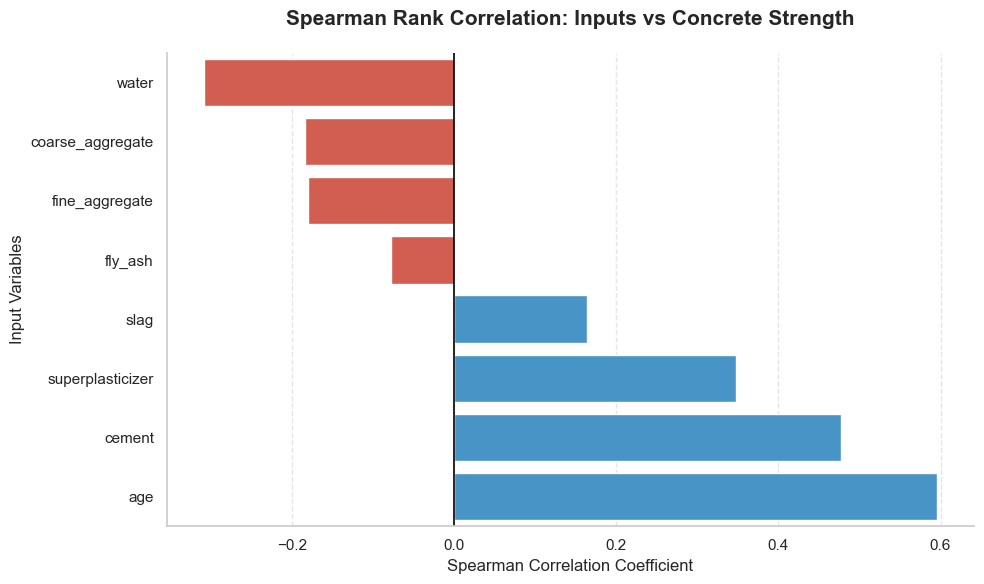


           KEY DATA INSIGHTS
1. PRIMARY DRIVER: 'AGE' has the strongest positive monotonic relationship (0.60). Increasing it usually results in higher strength.
2. PRIMARY INHIBITOR: 'WATER' has the strongest negative relationship (-0.31). Higher amounts tend to weaken the final product.

--- Variable Rankings (Impact on Strength) ---
 - Age                 :   0.60 (Increases strength)
 - Cement              :   0.48 (Increases strength)
 - Superplasticizer    :   0.35 (Increases strength)
 - Slag                :   0.16 (Increases strength)
 - Fly Ash             :  -0.08 (Decreases strength)
 - Fine Aggregate      :  -0.18 (Decreases strength)
 - Coarse Aggregate    :  -0.18 (Decreases strength)
 - Water               :  -0.31 (Decreases strength)


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming your dataframe is named 'raw_df' as per your prompt
# 1. Clean the column names (removing spaces)
raw_df.columns = [col.strip() for col in raw_df.columns]

# 2. Identify target column (Adjusting for the name 'strength' in your data)
target_col = 'strength' 

# 3. Compute Spearman Rank Correlation specifically against the output
# This ranks the monotonic relationship strength between each input and the output
spearman_corr = raw_df.corr(method='spearman')[target_col].drop(target_col).sort_values()

# 4. --- BEST PLOT: Sorted Horizontal Bar Chart ---
plt.figure(figsize=(10, 6))

# Use a diverging color palette (Red for negative, Blue for positive)
colors = ['#E74C3C' if x < 0 else '#3498DB' for x in spearman_corr.values]

sns.barplot(x=spearman_corr.values, y=spearman_corr.index, palette=colors)

# Professional Formatting
plt.title('Spearman Rank Correlation: Inputs vs Concrete Strength', 
          fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Spearman Correlation Coefficient', fontsize=12)
plt.ylabel('Input Variables', fontsize=12)
plt.axvline(0, color='black', lw=1.2) # Add a vertical line at zero for clarity
sns.despine() # Clean up the frame
plt.grid(axis='x', linestyle='--', alpha=0.5) # Soft grid for readability
plt.tight_layout()

# Show the plot
plt.show()

# --- SUMMARY OF INSIGHTS ---
print("\n" + "="*45)
print("           KEY DATA INSIGHTS")
print("="*45)

print(f"1. PRIMARY DRIVER: '{spearman_corr.idxmax().upper()}' has the strongest positive "
      f"monotonic relationship ({spearman_corr.max():.2f}). Increasing it usually results in higher strength.")

print(f"2. PRIMARY INHIBITOR: '{spearman_corr.idxmin().upper()}' has the strongest negative "
      f"relationship ({spearman_corr.min():.2f}). Higher amounts tend to weaken the final product.")

print("\n--- Variable Rankings (Impact on Strength) ---")
for var, val in spearman_corr.sort_values(ascending=False).items():
    direction = "Increases" if val > 0 else "Decreases"
    print(f" - {var.replace('_', ' ').title():<20}: {val:>6.2f} ({direction} strength)")
print("="*45)

Based on the Spearman Rank Correlation (which measures the strength and direction of monotonic relationships), here is the summary of how each input affects the **Concrete Compressive Strength**:

#### 1. Primary Growth Drivers (Positive Correlation)
* **Age (0.60):** The strongest factor. As the curing time increases, the concrete consistently gains strength. Spearman captures this non-linear growth trend more effectively than a standard linear correlation.
* **Cement (0.48):** The core binder. Increasing cement content is the most reliable way to chemically increase the load-bearing capacity of the mix.
* **Superplasticizer (0.35):** Shows a moderate positive relationship. These additives allow for better workability with less water, indirectly supporting higher strength.
* **Slag (0.16):** Provides a minor positive contribution to the final strength of the mixture.

#### 2. Primary Inhibitors (Negative Correlation)
* **Water (-0.31):** The strongest negative driver. In concrete chemistry, more water typically increases porosity and reduces density, leading to lower compressive strength.
* **Coarse & Fine Aggregates (-0.18):** Both show a slight negative correlation. This suggests that simply increasing the "filler" volume without adjusting the cement paste can dilute the overall strength.
* **Fly Ash (-0.08):** Shows a negligible negative correlation, suggesting its impact on strength is minimal or highly dependent on other variables in this specific dataset.

#### 3. Summary Ranking (From Most Positive to Most Negative)
| Variable | Correlation Score | Impact Direction |
| :--- | :--- | :--- |
| **Age** | +0.60 | 📈 Strong Increase |
| **Cement** | +0.48 | 📈 Moderate Increase |
| **Superplasticizer** | +0.35 | 📈 Low-Moderate Increase |
| **Slag** | +0.16 | 📈 Slight Increase |
| **Fly Ash** | -0.08 | 📉 Negligible Decrease |
| **Fine Aggregate** | -0.18 | 📉 Slight Decrease |
| **Coarse Aggregate** | -0.18 | 📉 Slight Decrease |
| **Water** | -0.31 | 📉 Moderate Decrease |

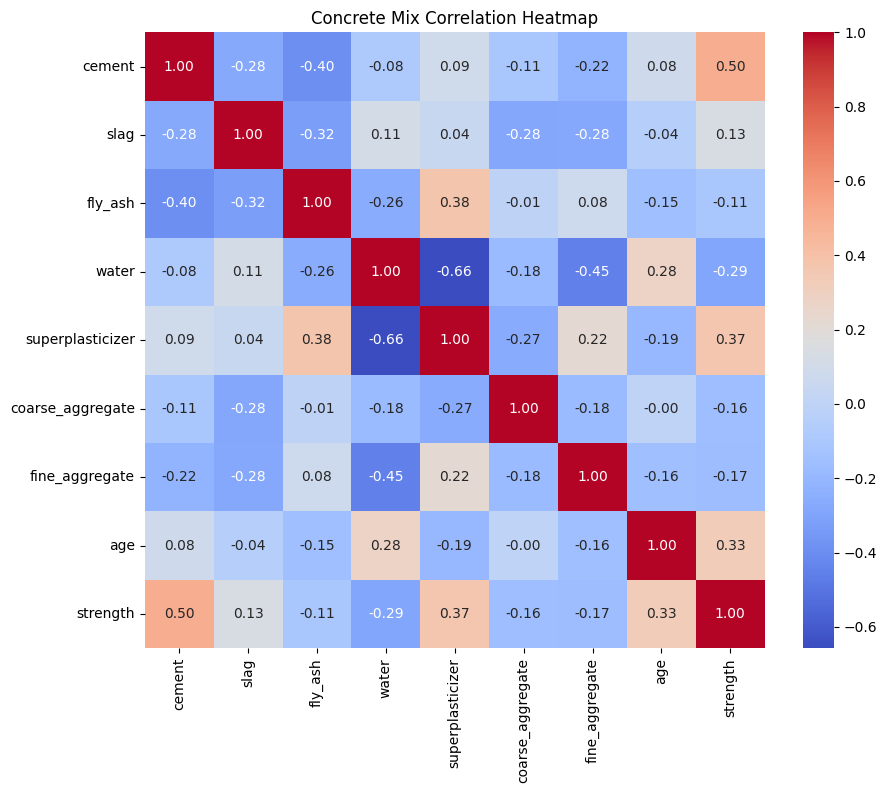

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

correlation_matrix = clean_concrete_data.corr()

plt.figure(figsize=(10, 8))

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Concrete Mix Correlation Heatmap")
plt.show()

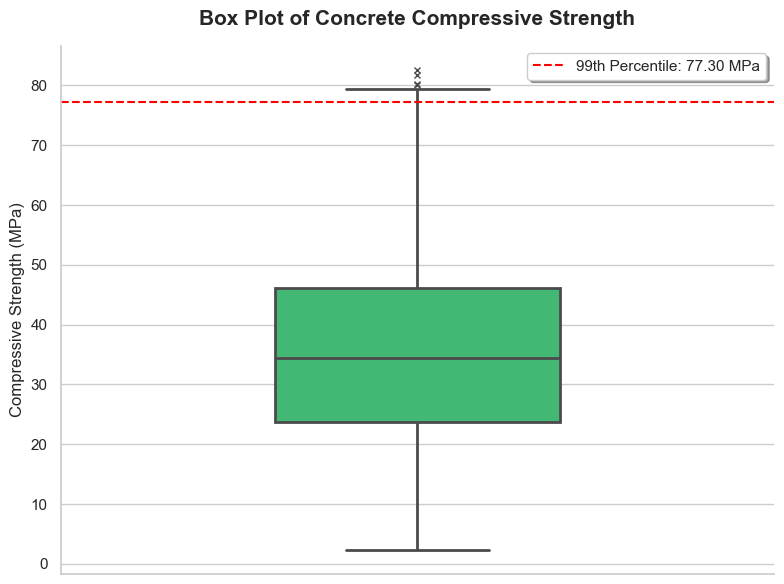

--- STATISTICAL RESULT ---
The 99th percentile value of concrete strength is: 77.30 MPa
Meaning: 99% of all samples fall below this strength level.


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Clean the column names (removing spaces)
# Ensure the column name matches your current dataframe state (e.g., 'strength')
raw_df.columns = [col.strip() for col in raw_df.columns]

# Check for the correct column name and rename if necessary to 'strength'
if 'concrete_compressive_strength' in raw_df.columns:
    raw_df = raw_df.rename(columns={'concrete_compressive_strength': 'strength'})

# 2. Calculate the 99th Percentile
# This means only 1% of the samples in the dataset have a strength higher than this value.
percentile_99 = raw_df['strength'].quantile(0.99)

# 3. Create the Box Plot
plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid")

# Create a clean, professional box plot
sns.boxplot(
    y=raw_df['strength'], 
    color='#2ECC71',     # Professional Emerald Green
    width=0.4, 
    linewidth=2, 
    fliersize=5,          # Size of outlier points
    flierprops={"marker": "x"} # Style for outliers
)

# 4. Add a horizontal line and label for the 99th percentile
plt.axhline(
    percentile_99, 
    color='red', 
    linestyle='--', 
    linewidth=1.5, 
    label=f'99th Percentile: {percentile_99:.2f} MPa'
)

# Professional Formatting
plt.title('Box Plot of Concrete Compressive Strength', fontsize=15, weight='bold', pad=15)
plt.ylabel('Compressive Strength (MPa)', fontsize=12)
plt.legend(loc='upper right', frameon=True, shadow=True)

sns.despine() # Remove top/right spines
plt.tight_layout()
plt.show()

# Print the result
print(f"--- STATISTICAL RESULT ---")
print(f"The 99th percentile value of concrete strength is: {percentile_99:.2f} MPa")
print(f"Meaning: 99% of all samples fall below this strength level.")

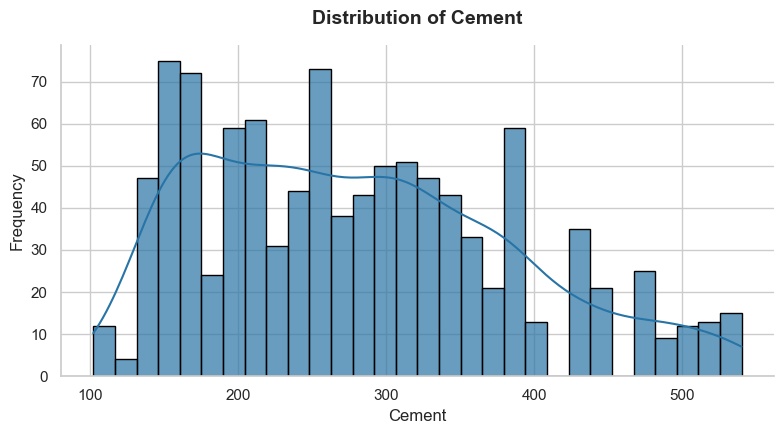

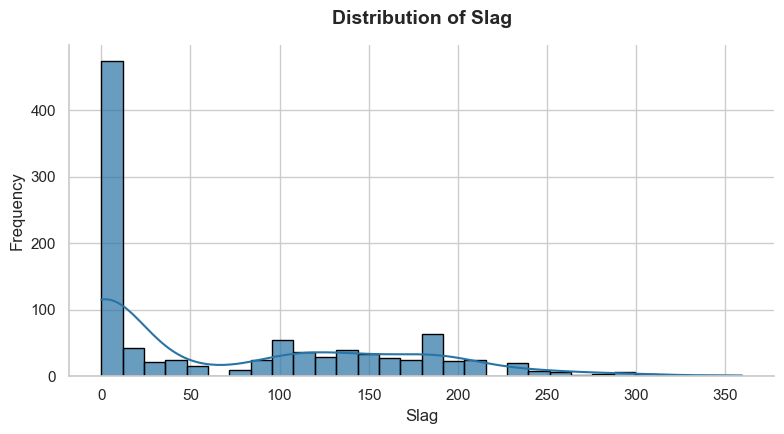

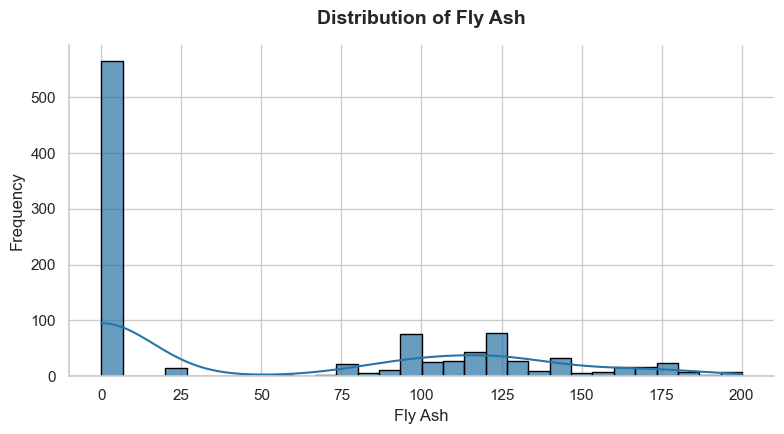

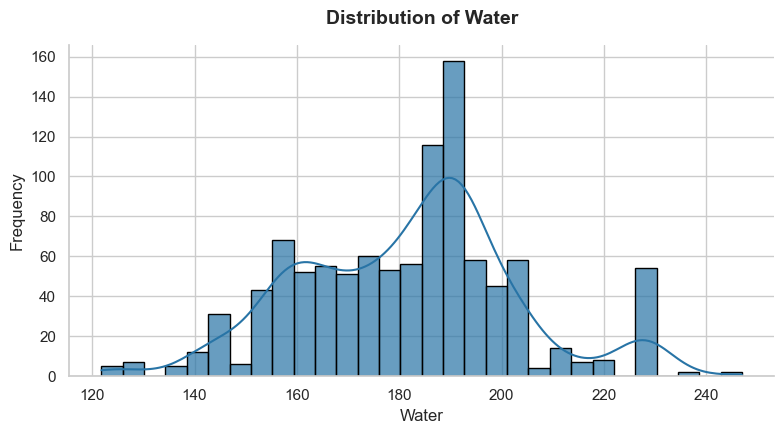

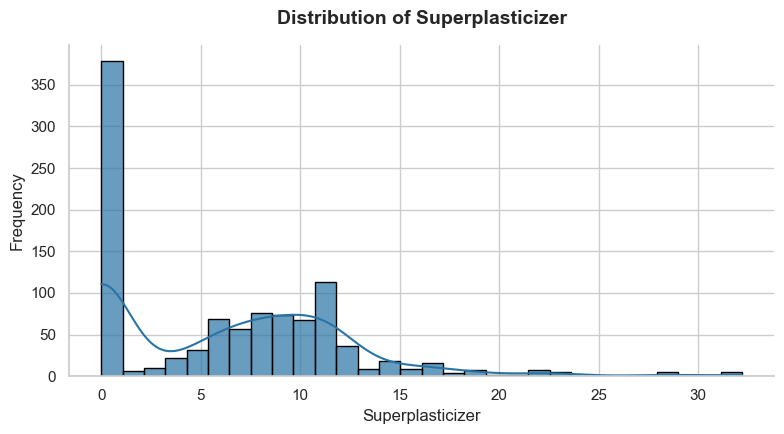

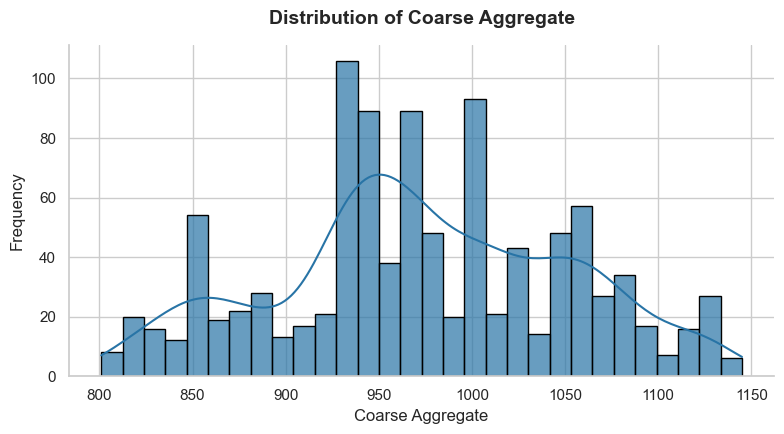

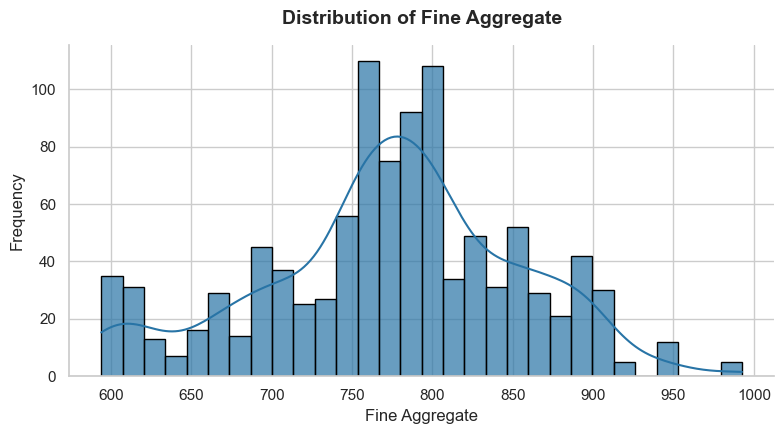

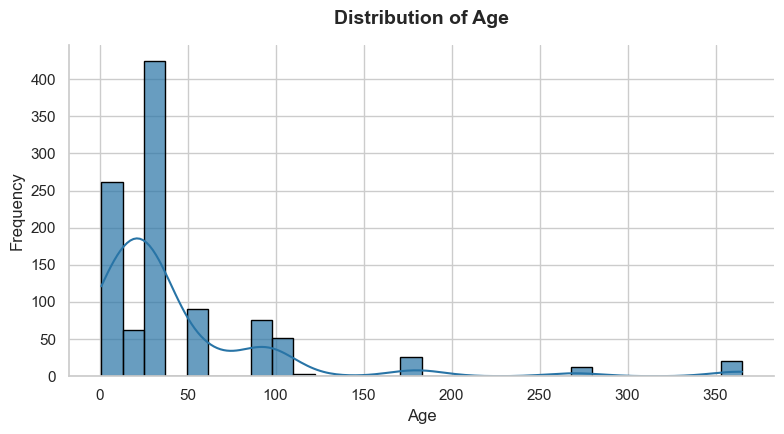

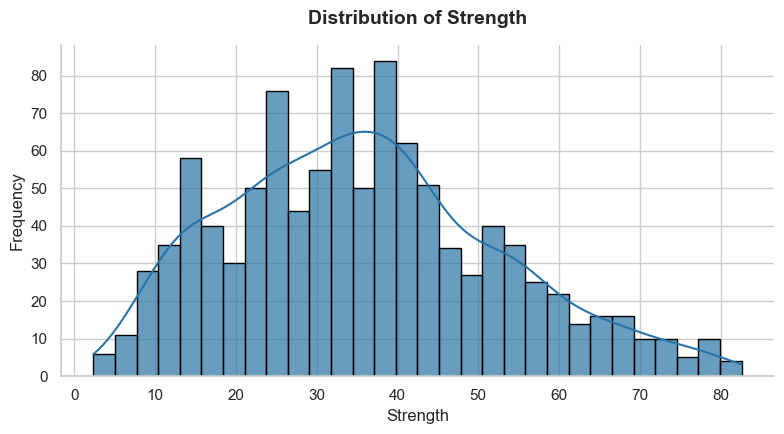

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming your dataframe is already loaded as raw_df
# raw_df = pd.read_csv('concrete_data.csv')

# 1. Clean up column names just in case there are trailing spaces in the CSV
raw_df.columns = [col.strip() for col in raw_df.columns]

# 2. Set a professional, clean theme using seaborn
sns.set_theme(style="whitegrid")

# 3. Iterate through every column to create independent graphs
for col in raw_df.columns:
    # Create an independent figure for each variable
    plt.figure(figsize=(8, 4.5))
    
    # Clean up the variable name for presentation (e.g., 'blast_furnace_slag' -> 'Blast Furnace Slag')
    clean_name = col.replace('_', ' ').title()
    
    # Plot a histogram with a Kernel Density Estimate (KDE) overlay
    sns.histplot(
        raw_df[col], 
        kde=True,               # Adds the smoothed curve line
        color='#2874A6',        # A professional dark blue
        bins=30,                # Number of bars
        edgecolor='black',      # Outlines the bars for clarity
        alpha=0.7               # Slight transparency
    )
    
    # Format Titles and Labels
    # Add units to the output variable for clarity
    if clean_name.lower() == 'concrete compressive strength':
        clean_name = 'Concrete Compressive Strength (MPa)'
        
    plt.title(f'Distribution of {clean_name}', fontsize=14, pad=15, weight='bold')
    plt.xlabel(clean_name, fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    
    # Remove top and right borders for a cleaner, modern look
    sns.despine()
    
    # Adjust layout to prevent clipping
    plt.tight_layout()
    
    # Display the plot
    plt.show()
    
    # Optional: If you want to save them instead of showing, replace plt.show() with:
    # plt.savefig(f"{col}_distribution.png", dpi=300)

In [9]:
spearman_corr = clean_concrete_data.corr(method='spearman')

strength_correlations = spearman_corr[['strength']].sort_values(by='strength', ascending=False)

print("Spearman Correlation with Compressive Strength:")
print(strength_correlations)

Spearman Correlation with Compressive Strength:
                    strength
strength            1.000000
total_binder        0.599406
age                 0.596028
cement              0.477614
superplasticizer    0.347786
slag                0.164105
fly_ash            -0.077830
fine_aggregate     -0.179962
coarse_aggregate   -0.183542
water              -0.308414
water_cement_ratio -0.522056
water_binder_ratio -0.605882


In [3]:
clean_concrete_data['water_cement_ratio'] = clean_concrete_data['water'] / clean_concrete_data['cement']

clean_concrete_data['total_binder'] = clean_concrete_data['cement'] + clean_concrete_data['slag'] + clean_concrete_data['fly_ash']

clean_concrete_data['water_binder_ratio'] = clean_concrete_data['water'] / clean_concrete_data['total_binder']

print(clean_concrete_data[['water', 'cement', 'water_cement_ratio', 'water_binder_ratio']].head())

   water  cement  water_cement_ratio  water_binder_ratio
0  162.0   540.0            0.300000             0.30000
1  162.0   540.0            0.300000             0.30000
2  228.0   332.5            0.685714             0.48000
3  228.0   332.5            0.685714             0.48000
4  192.0   198.6            0.966767             0.58006


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

X = clean_concrete_data.drop('strength', axis=1)
y = clean_concrete_data['strength']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_model = RandomForestRegressor(random_state=42)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

score = r2_score(y_test, y_pred)
print("Model R-squared Score:", score)

Model R-squared Score: 0.9093058412997821


In [5]:
from sklearn.model_selection import GridSearchCV

param_grid = {
'n_estimators': [50, 100, 150],
'max_depth': [10, 15, None],
'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(estimator=RandomForestRegressor(random_state=42), param_grid=param_grid, cv=5, scoring='r2')

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
final_pred = best_model.predict(X_test)

final_score = r2_score(y_test, final_pred)

print("Final Optimized R-squared Score:", final_score)
print("Best Settings Found:", grid_search.best_params_)

Final Optimized R-squared Score: 0.9070660808447684
Best Settings Found: {'max_depth': 15, 'min_samples_split': 2, 'n_estimators': 150}
